First import the image

In [1]:
# Imports
from PIL import Image
import colorsys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

# Import the image
img = Image.open("image324x324inside.jpg")
# img = Image.open("image324x324outside.jpg")
# img = Image.open("image_rot_1.JPG")

img.show()

Now we calculate the excess green and make a map

Max Length: %d 2276
Start Index: %d 1100
Total Length: %d 9927


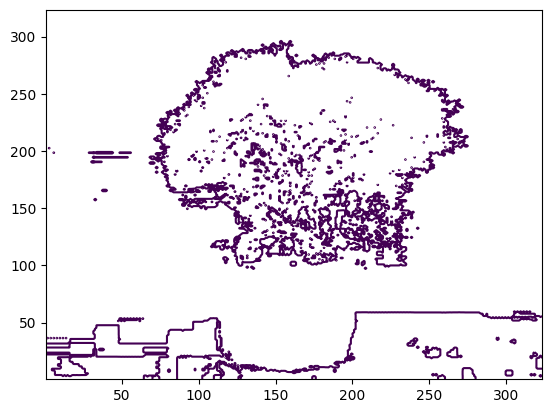

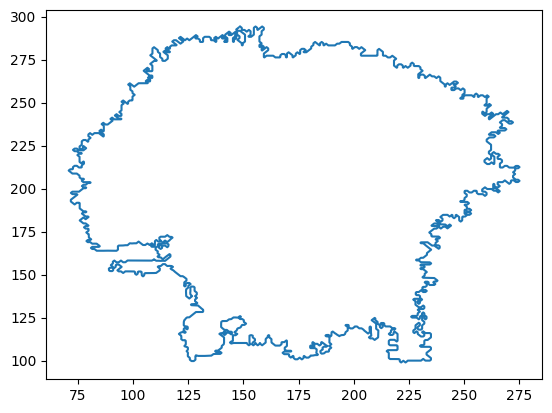

In [2]:
#values to tweak: lowest & highest hue, lowest sat, contour "levels" arg, 

cmap = cm.get_cmap('plasma') 

map = np.zeros((img.width, img.height))

reference_hue = 100 #green = 120, yellow = 60

lowest_hue = -75
lowest_hue = np.deg2rad(lowest_hue)
highest_hue = 50
highest_hue = np.deg2rad(highest_hue)

lowest_sat = .25 #best: ~.25
lowest_val = 0 # filtering by value is likely ineffective, but I included anyway

for x in range(img.width):
    for y in range(img.height):
        r, g, b = img.getpixel((x, y))
        h, s, v = colorsys.rgb_to_hsv(r,g,b)
        h = h * 360 - reference_hue
        h = np.deg2rad(h)

        if(lowest_hue < h < highest_hue):
            excess_green = np.cos(h)
        else:
            excess_green = 0
        if(s < lowest_sat or v < lowest_val):
            excess_green = 0
        

        map[x, y] = excess_green

# Normalize and reorient
map = map/np.max(map)
map = map.T

# Filter low values
threshold = 0.2
map[map < threshold] = 0

# Show map
map_colored = (cmap(map)[:, :, :3]*255).astype(np.uint8)
map_img = Image.fromarray(map_colored, 'RGB')
map_img.show()

# create contour "outline"
contour = plt.contour(map, levels=[.2], origin='image') #best: levels=[.2]
paths = contour.get_paths()
path = paths[0]

plt.figure()

points = []
ops = []
for vertices, code in path.iter_segments():
    points.append(vertices)
    ops.append(code)

points = np.array(points)
ops = np.array(ops)

length = 0
max_length = 0
start_index = 0
i = 0

for vertices, code in path.iter_segments():
    length = length + 1

    if code == 1:
        index = i

    if code == 79: # CLOSEPOLY = np.uint8(79)
        length = 0
    if length > max_length:
        max_length = length
        start_index = index
        
    i = i + 1
print("Max Length: %d",max_length)
print("Start Index: %d",start_index)
print("Total Length: %d",i-1)

outline = points[start_index:start_index + max_length]
plt.plot(outline[:, 0], outline[:, 1])

# Show map over original image
map = map.T
for x in range(img.width):
    for y in range(img.height):
        if map[x, y] >= threshold:
            r, g, b = map_img.getpixel((x, y))
            img.putpixel((x, y), (r, g, b))

img.show()